In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("phishing_email.csv")






Saving phishing_email.csv to phishing_email.csv


In [ ]:
# ----------------------------------------------------------------
# 1.  WORD LISTS  (whitelist + custom_noise)                      |
# ----------------------------------------------------------------
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# 🔒  PHISHING‑SIGNAL WORDS *never* to remove
keep_whitelist = {
    # finance / credential cues
    'financial', 'finance', 'bank', 'banking', 'payment', 'credit',
    'invoice', 'account', 'password', 'verify', 'login', 'update',
    'alert', 'money',

    # action / device / upgrade
    'require', 'required', 'apply', 'target', 'device', 'upgrade',

    # brand & misc high‑signal terms
    'microsoft',

    # numeric / technical context you want to keep
    'number', 'numbers', 'html', 'market', 'rate', 'return',
    'sale', 'tool', 'search', 'provide', 'important', 'form',
    'international'
}

# 🗑️  GENERIC / LOW‑SIGNAL WORDS  to drop
custom_noise = {
    # names / orgs
    'enron', 'hou', 'ect', 'vince', 'georgia', 'pn',

    # attachment / header junk
    'attached', 'mailing', 'url', 'image', 'jpg', 'recipient',
    'replica', 'watch', 'click', 'http', 'https',

    # high‑freq boring words
    'added', 'address', 'cmncom', 'con', 'daily', 'free', 'help',
    'information', 'make', 'need', 'new', 'news', 'notes', 'people',
    'said', 'send', 'submission', 'time', 'use', 'virus', 'want',
    'work', 'contact', 'know', 'network', 'message', 'list', 'mail',
    'file', 'receive', 'gas', 'using', 'data', 'sent', 'total',
    'wrote', 'university', 'business',

    # courtesy / footer fluff
    'thanks', 'dear', 'group', 'company', 'unsubscribe',

    # extra noise – adjectives, chit‑chat, corp filler
    'good', 'better', 'nice', 'able', 'large', 'long', 'hard', 'natural',
    'happy', 'forward', 'follow', 'tell', 'write', 'feel', 'believe',
    'person', 'names', 'thing', 'times', 'needed', 'weeks', 'days',
    'years', 'department', 'manager', 'meeting', 'meet', 'opportunity',
    'experience', 'solution', 'service', 'content', 'method', 'reason',
    'complete',

    # newest auto‑noise batch
    'look', 'available', 'right', 'computer', 'talk', 'says', 'makes',
    'small', 'away', 'fact', 'simple', 'wont', 'welcome', 'range',
    'provided', 'necessary', 'major', 'processing', 'friends',
    'interesting', 'direct', 'emails', 'left', 'bring', 'particular',
    'sign', 'approval', 'present', 'true', 'remember', 'member',
    'models', 'exactly', 'action', 'items', 'afternoon', 'drive',
    'past', 'join', 'seen', 'extra', 'started', 'sites', 'chance',
    'mind', 'turn', 'pipeline', 'hear',

    # month / geo / misc filler
    'month', 'september', 'america', 'allow', 'director', 'comes',
    'addresses', 'cases', 'vacation', 'plus', 'taking', 'design', 'enter',
    'suite', 'average', 'events', 'west', 'came', 'canada', 'hand',
    'house', 'wants', 'youll', 'party', 'section', 'self', 'national',
    'delivered', 'europe', 'unless', 'recently', 'known', 'cause',
    'supply', 'frank', 'leave', 'step', 'industry', 'young', 'ones',
    'prefer', 'situation', 'cover', 'avoid', 'active', 'accept',
    'unfortunately', 'ensure', 'thank', 'control', 'newsletter','line', 'normal','letter', 'sales','email', 'subject', 'like', 'think', 'dont', 'going', 'best',

     # logistic / boiler‑plate IDs
    'submissionid', 'sender', 'report', 'research', 'settings',

    # generic verbs / nouns
    'read', 'site', 'today', 'software', 'online', 'used',
    'cable', 'change', 'following', 'year', 'order',

    # domain fragment we already know is irrelevant
    'cnncom',

     # ⇣ newly added purely generic words
     'date', 'week',
    'program', 'systems', 'john', 'life', 'home', 'center', 'rights',
    'reply', 'received', 'original', 'language', 'python','world', 'code', 'support', 'services', 'internet', 'version',
    'based', 'papers', 'result', 'management', 'reserved',
    'regards', 'case', 'looking',





}

# combine scikit stop‑words + custom_noise, minus whitelist
all_noise = (ENGLISH_STOP_WORDS | custom_noise) - keep_whitelist
print(f"[info] custom_noise size  : {len(custom_noise)}")
print(f"[info] combined noise size: {len(all_noise)}")


# ================================================================
# 2.  CLEANING PIPELINE  -----------------------------------------
# ================================================================
import re
def basic_cleaning(txt: str) -> str:
    txt = str(txt).lower()
    txt = re.sub(r"http\S+|www\.\S+", " url ", txt)          # keep literal 'url'
    txt = re.sub(r"[^a-z\s]", " ", txt)                      # keep a‑z only
    txt = re.sub(r"\b[a-z]*\d+[a-z]*\b", " ", txt)           # drop alphanum tokens
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt

def remove_noise_words(txt: str) -> str:
    return " ".join([w for w in txt.split() if w not in all_noise])

def remove_short_tokens(txt: str) -> str:
    return " ".join([w for w in txt.split() if len(w) > 3])  # ≥4 chars

df["text_cleaned"] = (
    df["text_combined"]
      .apply(basic_cleaning)
      .apply(remove_noise_words)
      .apply(remove_short_tokens)
)

# ================================================================
# 3.  TRAIN / TEST SPLIT  ----------------------------------------
# ================================================================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df["text_cleaned"], df["label"],
    test_size=0.10, random_state=42, stratify=df["label"]
)
print(f"[info] train / test sizes : {len(X_train)} / {len(X_test)}")

# ================================================================
# 4.  VECTORS  +  RANDOM FOREST  ---------------------------------
# ================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

tfidf_vec = TfidfVectorizer(max_features=5000,
                            min_df=5,
                            token_pattern=r"(?u)\b[a-z]{4,}\b")

Xtr = tfidf_vec.fit_transform(X_train)
Xte = tfidf_vec.transform(X_test)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight="balanced",
    random_state=42
).fit(Xtr, y_train)

print("\n=== TF‑IDF report ===")
print(classification_report(y_test, rf_clf.predict(Xte), digits=3))

# ================================================================
# 5.  FEATURE  TABLE  (freq, chi², RF‑importance)  ---------------
# ================================================================
from sklearn.feature_selection import chi2
import pandas as pd

chi2_scores, _ = chi2(Xtr, y_train)
feat_df = pd.DataFrame({
    "token" : tfidf_vec.get_feature_names_out(),
    "freq"  : np.asarray(Xtr.sum(axis=0)).ravel(),
    "chi2"  : chi2_scores,
    "rf_imp": rf_clf.feature_importances_,
})

# ================================================================
# 6.  AUTO‑SUGGEST  EXTRA NOISE  TOKENS  --------------------------
#    • Adjust thresholds, run this cell,
#    • Copy any true junk back into `custom_noise`, then rerun 1‑4.
# ================================================================
THRESH_FREQ  = 120       # appears in ≥ 120 docs
THRESH_CHI2  = 6         # very weak label association
THRESH_RFIMP = 0.00020   # negligible RF importance

auto_noise = (feat_df
              .query(f"freq > {THRESH_FREQ}"
                     f" and chi2 < {THRESH_CHI2}"
                     f" and rf_imp < {THRESH_RFIMP}")
              .sort_values("freq", ascending=False)["token"]
              .tolist())

auto_noise = [w for w in auto_noise if w not in keep_whitelist]

print(f"\n🟡  Suggested noise words ({len(auto_noise)})\n"
      f"    → copy into custom_noise & rerun sections 1‑4")
print(auto_noise[:60])   # show first 60 suggestions


[info] custom_noise size  : 250
[info] combined noise size: 567
[info] train / test sizes : 74237 / 8249

=== TF‑IDF report ===
              precision    recall  f1-score   support

           0      0.933     0.867     0.899      3960
           1      0.885     0.942     0.913      4289

    accuracy                          0.906      8249
   macro avg      0.909     0.905     0.906      8249
weighted avg      0.908     0.906     0.906      8249


🟡  Suggested noise words (10)
    → copy into custom_noise & rerun sections 1‑4
['phone', 'interested', 'performance', 'share', 'president', 'communication', 'notification', 'rest', 'mailbox', 'play']


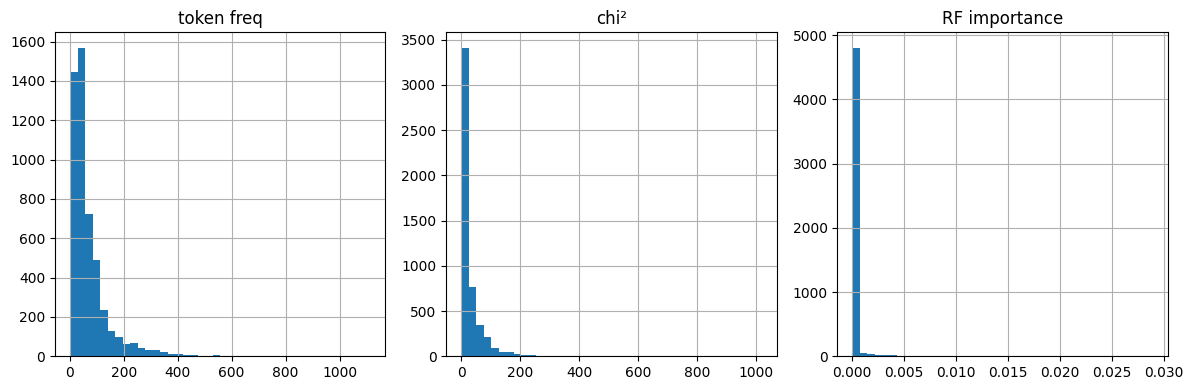

         count       mean        std           min        25%        50%  \
freq    5000.0  69.889866  76.536612  6.963901e-01  26.494426  43.882230   
chi2    5000.0  28.544676  47.167354  4.397884e-07   3.918821  13.625514   
rf_imp  5000.0   0.000200   0.001207  0.000000e+00   0.000001   0.000009   

              75%          max  
freq    84.694387  1114.428092  
chi2    33.423012  1017.522988  
rf_imp   0.000032     0.028900  


In [ ]:
# ── quick histogram / stats to understand ranges ─────────────
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
feat_df['freq'   ].hist(bins=40); plt.title('token freq')
plt.subplot(1,3,2)
feat_df['chi2'   ].hist(bins=40); plt.title('chi²')
plt.subplot(1,3,3)
feat_df['rf_imp' ].hist(bins=40); plt.title('RF importance')
plt.tight_layout()
plt.show()

print(feat_df[['freq','chi2','rf_imp']].describe().T)


In [ ]:
# ---- auto‑suggest phase 2 -------------------------------------------
THRESH_FREQ  =  6000     # appear in ≥ 6 k docs  (≈ top 0.5 %)
THRESH_CHI2  =     4     # very weak label link
THRESH_RFIMP = 0.00015   # almost zero importance

auto_noise = (feat_df
              .query(f"freq > {THRESH_FREQ}"
                     f" and chi2 < {THRESH_CHI2}"
                     f" and rf_imp < {THRESH_RFIMP}")
              .sort_values('freq', ascending=False)['token']
              .tolist())

auto_noise = [w for w in auto_noise if w not in keep_whitelist]
print(f"Suggested noise words ({len(auto_noise)}):")
print(auto_noise)


Suggested noise words (0):
[]


In [ ]:
# ── tweak thresholds & rerun ──────────────────────────
THRESH_FREQ  = 120          # token must appear in > 60 docs
THRESH_CHI2  = 6           # χ² < 6  →  very weak label association
THRESH_RFIMP = 0.00020     # RF importance < 0.0002

auto_noise = (
    feat_df
      .query(
          f"freq  > {THRESH_FREQ}"
          f" and chi2 < {THRESH_CHI2}"
          f" and rf_imp < {THRESH_RFIMP}"
      )
      .sort_values('freq', ascending=False)['token']
      .tolist()
)

print(f"\n🟡  Suggested noise words  ({len(auto_noise)})")
print(auto_noise[:50])       #



🟡  Suggested noise words  (30)
['number', 'phone', 'return', 'provide', 'market', 'interested', 'international', 'required', 'html', 'important', 'search', 'financial', 'performance', 'numbers', 'tool', 'sale', 'microsoft', 'share', 'president', 'finance', 'communication', 'notification', 'device', 'target', 'apply', 'require', 'upgrade', 'rest', 'mailbox', 'play']


In [ ]:
# Show side-by-side comparison of original vs cleaned text
print("===== ORIGINAL vs CLEANED SAMPLE =====")
for i in range(3):
    print(f"[Sample {i+1}]")
    print("Original:")
    print(df['text_combined'].iloc[i])
    print("\nCleaned:")
    print(df['text_cleaned'].iloc[i])
    print("="*80)


===== ORIGINAL vs CLEANED SAMPLE =====
[Sample 1]
Original:
hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls

Cleaned:
hplno hplno
[Sample 2]
Original:
nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen ponton 05 29 2001 08 37 davilal txu com cstonel txu com mjones 7 txu com hpl scheduling enron com liz bellamy enron com szajac enron com cc subject nom actual vols 24 th agree nomination 33 750 forwarded eileen ponton houston pefs pec 05 29 01 08 36 charlie stone eileen ponton melissa jones com hpl scheduling enron com liz bellamy enron com szajac enron com 05 25 01 subject nom actual vols 24 th 04 23 pm agree nominated volume records reflect following nom schedule 30 rate eff 0900 hrs hour beginning 1400 hrs 6 250 60 rate eff 1400 hrs hour beginning 1700 hrs 7 500 30 rate eff 1700 hrs hour beginning 0900 hrs 20 000 total nominated 33 750 please review source data let us know agree thanks ccs eileen ponton 

In [ ]:
from collections import Counter

all_words = " ".join(df['text_cleaned']).split()
common_words = Counter(all_words).most_common(30)

print("===== Top 30 Frequent Words AFTER Cleaning =====")
for word, count in common_words:
    print(f"{word}: {count}")


===== Top 30 Frequent Words AFTER Cleaning =====
money: 19834
account: 18667
bank: 12033
million: 11842
price: 11690
number: 11676
deal: 10922
energy: 10839
security: 10805
power: 10276
market: 9288
conference: 9177
alert: 9013
problem: 8872
offer: 8168
transaction: 7762
great: 7630
future: 7621
visit: 7574
check: 7554
user: 7517
provide: 7504
investment: 7469
process: 7383
details: 7373
corp: 7364
start: 7311
issue: 7281
possible: 7203
come: 7120


In [ ]:
from itertools import chain

# Check which custom noise words are still present after cleaning
token_sets = df['text_cleaned'].apply(lambda text: set(text.split()))
all_tokens = set(chain.from_iterable(token_sets))
residual_noise = [word for word in custom_noise if word in all_tokens]

print("\n====== Remaining Custom Noise Words (Should Be Empty) ======")
print(residual_noise)



====== Remaining Custom Noise Words (Should Be Empty) ======
[]


In [ ]:
# ================================================================
# 7.  Inspect top‑N TF‑IDF features driving the Random Forest
# ================================================================
from sklearn.metrics import classification_report
import numpy as np

# ── A. quick evaluation ─────────────────────────────────────────
print("\n=== Classification Report (TF‑IDF / RF) ===")
print(classification_report(y_test, rf_clf.predict(Xte), digits=3))

# ── B. top‑N words by RF importance ─────────────────────────────
N = 30                                         # how many to display
feature_names = tfidf_vec.get_feature_names_out()
importances   = rf_clf.feature_importances_

top_idx = np.argsort(importances)[-N:][::-1]   # largest → smallest

print(f"\n=== Top {N} Important TF‑IDF Words ===")
for i in top_idx:
    print(f"{feature_names[i]:15} : {importances[i]:.5f}")




=== Classification Report (TF‑IDF / RF) ===
              precision    recall  f1-score   support

           0      0.933     0.867     0.899      3960
           1      0.885     0.942     0.913      4289

    accuracy                          0.906      8249
   macro avg      0.909     0.905     0.906      8249
weighted avg      0.908     0.906     0.906      8249


=== Top 30 Important TF‑IDF Words ===
money           : 0.02890
watches         : 0.02324
problem         : 0.01776
warner          : 0.01761
forwarded       : 0.01759
questions       : 0.01673
love            : 0.01621
issues          : 0.01481
account         : 0.01435
issue           : 0.01423
opensuse        : 0.01361
doesnt          : 0.01341
houston         : 0.01289
atlanta         : 0.01232
kaminski        : 0.01122
manage          : 0.01102
health          : 0.01100
offer           : 0.01093
million         : 0.01069
dollars         : 0.01022
preference      : 0.01012
probably        : 0.01004
thats           :

In [ ]:
feature_names = tfidf_vec.get_feature_names_out()
importances   = rf_clf.feature_importances_
feature_importance = sorted(
        zip(feature_names, importances),
        key=lambda x: x[1],
        reverse=True)

# Define top N features from RandomForest as "important"
important_words = set([word for word, score in feature_importance[:30]])

# Define top N frequent words from text_cleaned
top_frequent_words = set([word for word, count in common_words[:30]])

# Suggest stopwords: frequent but not important
suggested_noise_words = sorted(top_frequent_words - important_words)

print("\n=== 🚫 Suggested Noise Words (High Frequency, Low Importance) ===")
print(suggested_noise_words)



=== 🚫 Suggested Noise Words (High Frequency, Low Importance) ===
['alert', 'check', 'come', 'deal', 'details', 'energy', 'future', 'great', 'investment', 'market', 'number', 'possible', 'power', 'price', 'process', 'provide', 'security', 'start', 'transaction', 'visit']


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vec = CountVectorizer(
    max_features=5000,
    min_df=5,
    token_pattern=r"(?u)\b[a-z]{4,}\b"
)

# X_train、X_test  train_test_split
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define a separate Random Forest model for BoW features
rf_bow = RandomForestClassifier(
    n_estimators=100,            # number of trees
    max_depth=15,                # limit tree depth
    max_samples=0.8,             # use 80% of training data
    max_features='sqrt',        # sqrt of total features
    bootstrap=True,             # bootstrap sampling
    class_weight='balanced',    # handle class imbalance
    random_state=42
)

# Train the model on BoW features
rf_bow.fit(X_train_bow, y_train)



RandomForestClassifier(class_weight='balanced', max_depth=15, max_samples=0.8,
                       random_state=42)

In [ ]:
# Predict with the BoW-trained model on the test set
y_pred_bow = rf_bow.predict(X_test_bow)


# Print classification report and confusion matrix for BoW model
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report for BoW:\n")
print(classification_report(y_test, y_pred_bow, digits=4))

print("\nConfusion Matrix for BoW:")
print(confusion_matrix(y_test, y_pred_bow))


Classification Report for BoW:

              precision    recall  f1-score   support

           0     0.9411    0.8437    0.8897      3960
           1     0.8683    0.9513    0.9079      4289

    accuracy                         0.8996      8249
   macro avg     0.9047    0.8975    0.8988      8249
weighted avg     0.9032    0.8996    0.8992      8249


Confusion Matrix for BoW:
[[3341  619]
 [ 209 4080]]


The BoW-based Random Forest model exhibits significantly lower performance compared to the TF-IDF model. Precision, recall, and F1 scores hover around 0.48 to 0.51, indicating poor discriminatory power between legitimate and phishing emails. The overall accuracy is approximately 49.8%, close to random guessing. The confusion matrix shows a high number of misclassifications, with many false positives and false negatives. This suggests that the BoW representation is insufficient for capturing the relevant features needed for effective phishing detection in this dataset.

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score
# Initialize another Random Forest model for BoW with same parameters
rf_bow = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    max_samples=0.8,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    random_state=42
)

# Perform 5-fold cross-validation using BoW features
scores_bow = cross_val_score(rf_bow, X_train_bow, y_train, cv=5, scoring='f1')
print("BoW F1 scores from each fold:", scores_bow)
print("BoW Average F1 score:", np.mean(scores_bow))


BoW F1 scores from each fold: [0.91530498 0.91078182 0.91191967 0.90945323 0.91429995]
BoW Average F1 score: 0.9123519296915354


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Improved Random Forest Classifier with regularization to prevent overfitting
rf = RandomForestClassifier(
    n_estimators=100,         # number of trees
    max_depth=15,             # limit tree depth
    max_samples=0.8,          # use 80% of training samples
    max_features='sqrt',      # sqrt of total features
    bootstrap=True,           # bootstrap sampling
    class_weight='balanced',  # handle class imbalance
    random_state=42
)


# Perform 5-fold cross-validation on training set
scores = cross_val_score(rf, X_train_tfidf, y_train, cv=5, scoring='f1')

print("TF-IDF F1 scores from each fold:", scores)
print("TF-IDF Average F1 score:", np.mean(scores))


NameError: name 'X_train_tfidf' is not defined

In [ ]:
# ===============================
# Train the final model on the full training data
# ===============================
rf.fit(X_train_tfidf, y_train)

# ===============================
# Predict on the test data
# ===============================
y_pred = rf.predict(X_test_tfidf)

# ===============================
# Evaluate the results
# ===============================
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report for TF-IDF:\n")
print(classification_report(y_test, y_pred, digits=4))

print("Confusion Matrix for TF-IDF:\n")
print(confusion_matrix(y_test, y_pred))


The classification report and confusion matrix above demonstrate that the TF-IDF based Random Forest model performs well on the test dataset. The model achieves high precision, recall, and F1 scores for both classes, indicating effective discrimination between legitimate and phishing emails. The overall accuracy is 95.21%, and the balanced macro and weighted averages suggest consistent performance across classes. The confusion matrix shows a relatively low number of misclassifications, with 263 false positives and 132 false negatives, reflecting good model reliability for practical phishing detection.

In [ ]:
import matplotlib.pyplot as plt

# Create a figure with custom size
plt.figure(figsize=(8, 5))

# Plot TF-IDF model's F1 scores
plt.plot(scores, label='TF-IDF', marker='o', linestyle='-', color='blue')

# Plot BoW model's F1 scores
plt.plot(scores_bow, label='BoW', marker='o', linestyle='--', color='green')

# Add average scores as horizontal lines (optional)
plt.axhline(np.mean(scores), color='blue', linestyle=':', linewidth=1, label='TF-IDF Avg')
plt.axhline(np.mean(scores_bow), color='green', linestyle=':', linewidth=1, label='BoW Avg')

# Title and axes
plt.title('5-Fold Cross-Validation F1 Score: TF-IDF vs BoW')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.ylim(0, 1)

# Add legend and grid
plt.legend()
plt.grid(True)

# Show plot
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
# Train the BoW model if not done yet
rf_bow.fit(X_train_bow, y_train)

rf.fit(X_train_tfidf, y_train)


# Predict probabilities for BoW
y_proba_bow = rf_bow.predict_proba(X_test_bow)[:, 1]

# Predict probabilities for TF-IDF
y_proba_tfidf = rf.predict_proba(X_test_tfidf)[:, 1]

# Compute ROC curve for both
fpr_tfidf, tpr_tfidf, _ = roc_curve(y_test, y_proba_tfidf)
fpr_bow, tpr_bow, _ = roc_curve(y_test, y_proba_bow)

# Plot ROC curves
plt.figure(figsize=(6, 4))
plt.plot(fpr_tfidf, tpr_tfidf, color='darkorange', lw=2,
         label=f'TF-IDF ROC curve (AUC = {roc_auc_score(y_test, y_proba_tfidf):.4f})')
plt.plot(fpr_bow, tpr_bow, color='navy', lw=2,
         label=f'BoW ROC curve (AUC = {roc_auc_score(y_test, y_proba_bow):.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  # diagonal baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
